# **Regression analysis**
* Regression im statstics is te process of predicting a label(or Dependet variable) based on the features(Independent variable).
* Regression analysis is a form of predictive modelling techique which investigates the realashion ship between a dependent (target) and independent variables(predictor).
* Here, we fit a curve/ line to the data points ,in such a manner that the differences between the distances of data points from the curve or line is minimized.
* This tecqunique is used for forecasting and finding the relationship between the variables.

**The use of Regression:**
* Regression analysis predict the relationship between two or more features.

     The benifit of using regresion analysis are as follows:
 * it shows the significant relationships between the label and the features.
 * it indicates th strength of impact of multiple independent variabales o dependent variables
 
These benefits help market researchers / data analyst / data scientists to eliminat and
evaluate the best set of variables to be used for building predictive models.

# **LINEAR REGRESSION**

* Regression models are used to predict the continous values.
* It is supervised techmique.
* **Linear Regression** is a stastical analysis for predicting the values of a quantitative variable.
* In this technique , the dependent variable is continous ,independent variable can be contionous or discrete , and nature of regression line is linear.

* Linear reression establishes a relationship between dependent variable(Y) and one or more independent variables (X)inpendent variables(X) used in a best fit straight line(also known as regression line).

\begin{equation}Y=mx+be\end{equation}

where,

**y** is dependent variable

**x** is independent variable

**b** is intercept of y

**m** is the slope of the line

**e** is the error term

 **Predicting Housing Prices** 
 In this Project , I will develop several models that will predict the price of the House using the variables or features. This is just an estimate but should give us an objective idea of how much the House should cost in USA.


 The data contains the following columns:

1. **Avg. Area Income: Avg**: Income of residents of the city house is located in.
2.**Avg. Area House Age**: Avg Age of Houses in same city
3. **Avg. Area Number of Rooms**: Avg Number of Rooms for Houses in same city
4. **Avg. Area Number of Bedrooms**: Avg Number of Bedrooms for Houses in same city
5. **Area Population**: Population of city hou se is located in
6. **Price**: Price that the house sold at
7. **Address**: Address for the house



Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas
%matplotlib inline

# sns.set_style("whitegrid")
# plt.style.use("fivethirtyeight")

Import the data

In [5]:
Data = pd.read_csv('USA_Housing.csv')

Check out the Data

In [6]:
Data.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [7]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [8]:
Data.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [9]:
Data.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

**Exploratory Data Analysis (EDA)**

Let's create some simple plots to check out the data!

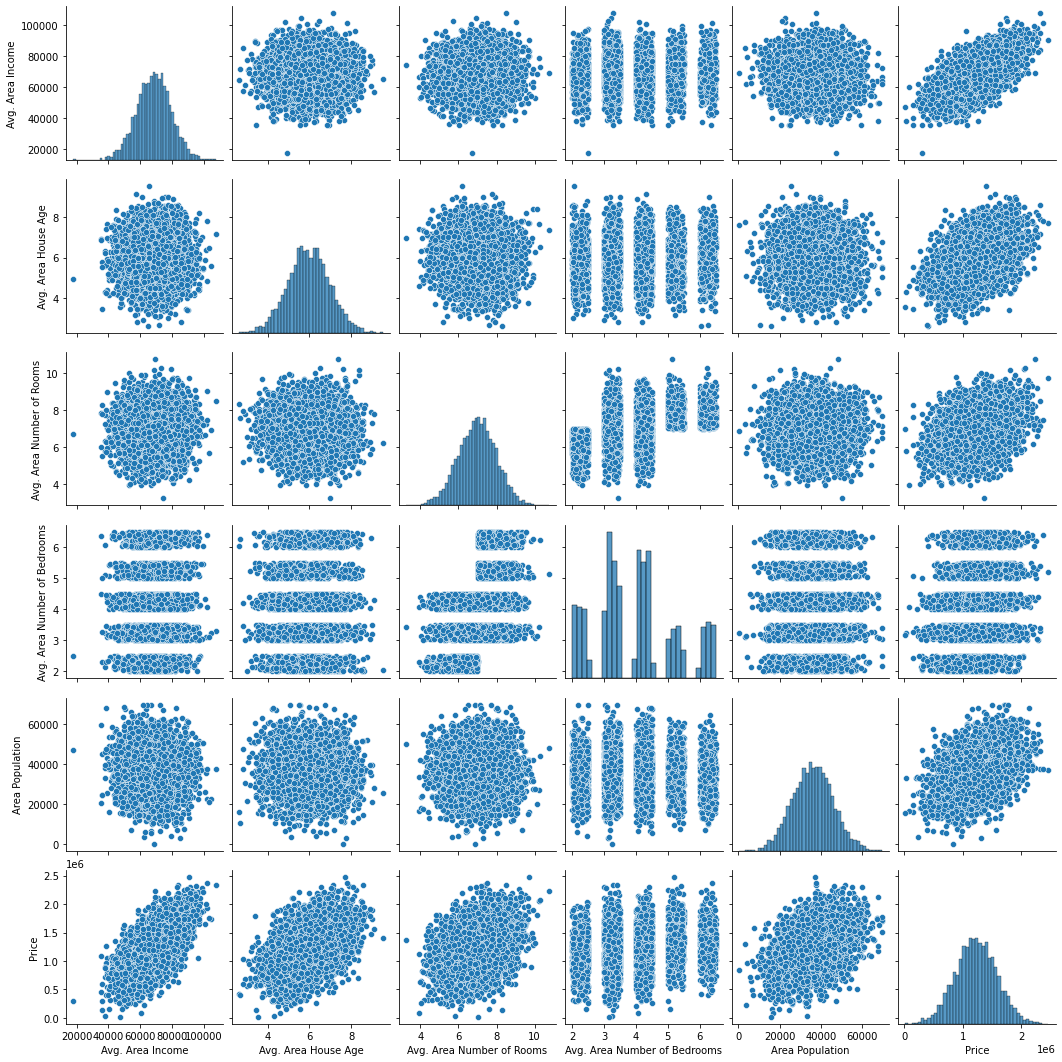

In [10]:
sns.pairplot(Data)

In [11]:
Data.hvplot.hist(by='Price', subplots=False, width=1000)

:NdOverlay   [Element]
   :Histogram   [Area Population]   (Area Population_count)

In [12]:
Data.hvplot.hist("Price")

:Histogram   [Price]   (Price_count)

In [13]:
Data.hvplot.scatter(x='Avg. Area House Age', y='Price')

:Scatter   [Avg. Area House Age]   (Price)

In [14]:
Data.hvplot.scatter(x='Avg. Area Income', y='Price')

:Scatter   [Avg. Area Income]   (Price)

In [15]:
Data.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

<AxesSubplot:>

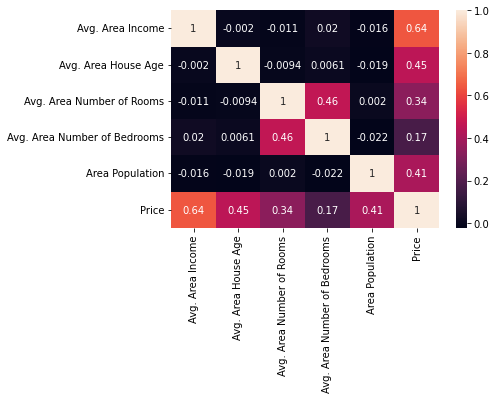

In [16]:
sns.heatmap(Data.corr(), annot=True)

**Distribution of Housing Price Across USA**

C:\Users\Lenovo\opencv\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Price', ylabel='Density'>

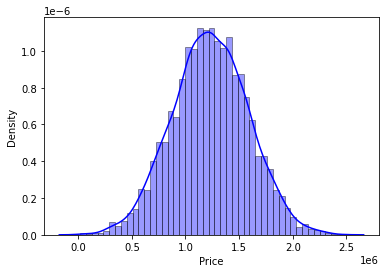

In [17]:
sns.distplot(Data['Price'],hist_kws=dict(edgecolor="black", linewidth=1),color='Blue')

**Training a Linear Regression Model**

Let's now begin to train out regression model! We will need to first split up our data into an X array that contains the features to train on, and a y array with the target variable, in this case the Price column. We will toss out the Address column because it only has text info that the linear regression model can't use.

In [18]:
#X and y arrays
X = Data[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population']]
y = Data['Price']

**Train Test Split**

Now let's split the data into a training set and a testing set. We will train out model on the training set and then use the test set to evaluate the model.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
from sklearn import metrics
from sklearn.model_selection import cross_val_score

def cross_val(model):
    pred = cross_val_score(model, X, y, cv=10)
    return pred.mean()

def print_evaluate(true, predicted):  
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2_square = metrics.r2_score(true, predicted)
    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)
    print('R2 Square', r2_square)
    print('__________________________________')
    
def evaluate(true, predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2_square = metrics.r2_score(true, predicted)
    return mae, mse, rmse, r2_square

**Preparing Data For Linear Regression**

Linear regression is been studied at great length, and there is a lot of literature on how your data must be structured to make best use of the model.

As such, there is a lot of sophistication when talking about these requirements and expectations which can be intimidating. In practice, you can uses these rules more as rules of thumb when using Ordinary Least Squares Regression, the most common implementation of linear regression.

Try different preparations of your data using these heuristics and see what works best for your problem.

1. **Linear Assumption:** Linear regression assumes that the relationship between your input and output is linear. It does not support anything else. This may be obvious, but it is good to remember when you have a lot of attributes. You may need to transform data to make the relationship linear (e.g. log transform for an exponential relationship).
2. **Remove Noise:** Linear regression assumes that your input and output variables are not noisy. Consider using data cleaning operations that let you better expose and clarify the signal in your data. This is most important for the output variable and you want to remove outliers in the output variable (y) if possible.
3. **Remove Collinearity:** Linear regression will over-fit your data when you have highly correlated input variables. Consider calculating pairwise correlations for your input data and removing the most correlated.
4. **Gaussian Distributions:** Linear regression will make more reliable predictions if your input and output variables have a Gaussian distribution. You may get some benefit using transforms (e.g. log or BoxCox) on you variables to make their distribution more Gaussian looking.
4. **Rescale Inputs:** Linear regression will often make more reliable predictions if you rescale input variables using standardization or normalization.

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('std_scalar', StandardScaler())
])

X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)

**Linear Regression**

In [22]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression(normalize=True)
lin_reg.fit(X_train,y_train)

C:\Users\Lenovo\opencv\lib\site-packages\sklearn\linear_model\_base.py:145: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2.
If you wish to scale the data, use Pipeline with a StandardScaler in a preprocessing stage. To reproduce the previous behavior:

from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(with_mean=False), LinearRegression())

If you wish to pass a sample_weight parameter, you need to pass it as a fit parameter to each step of the pipeline as follows:

kwargs = {s[0] + '__sample_weight': sample_weight for s in model.steps}
model.fit(X, y, **kwargs)


  FutureWarning,


LinearRegression(normalize=True)

**Model Evaluation**

Let's evaluate the model by checking out it's coefficients and how we can interpret them.

In [23]:
# print the intercept
print(lin_reg.intercept_)

1228219.1492415662


In [24]:
coeff_df = pd.DataFrame(lin_reg.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Area Income,232679.724643
Avg. Area House Age,163841.046593
Avg. Area Number of Rooms,121110.555478
Avg. Area Number of Bedrooms,2892.815119
Area Population,151252.342377


Interpreting the coefficients:

* Holding all other features fixed, a 1 
unit increase in Avg. Area Income is associated with an increase of $21.52.

* Holding all other features fixed, a 1 unit increase in Avg. Area House Age is associated with an increase of $164883.28.

* Holding all other features fixed, a 1 unit increase in Avg. Area Number of Rooms is associated with an increase of $122368.67.

* Holding all other features fixed, a 1 unit increase in Avg. Area Number of Bedrooms is associated with an increase of $2233.80.

* Holding all other features fixed, a 1 unit increase in Area Population is associated with an increase of $15.15.



**Predictions from our Model**

Let's grab predictions off our test set and see how well it did

In [25]:
pred = lin_reg.predict(X_test)

In [26]:
pd.DataFrame({'True Values': y_test, 'Predicted Values': pred}).hvplot.scatter(x='True Values', y='Predicted Values')

:Scatter   [True Values]   (Predicted Values)

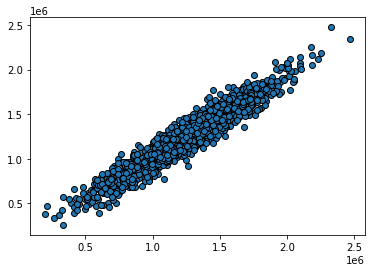

In [27]:
plt.scatter(y_test,pred, edgecolor='black')

Residual Histogram

In [28]:
pd.DataFrame({'Error Values': (y_test - pred)}).hvplot.kde()

:Distribution   [Error Values]   (Density)

C:\Users\Lenovo\opencv\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Price', ylabel='Density'>

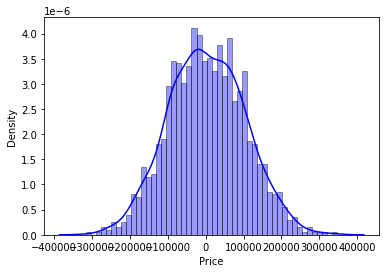

In [29]:
sns.distplot((y_test - pred), bins = 50, hist_kws=dict(edgecolor="black", linewidth=1),color='Blue')

# **Regression Evaluation Metrics**

Here are three common evaluation metrics for regression problems:

1. **Mean Absolute Error** (MAE) is the mean of the absolute value of the errors:
\begin{equation}\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|\end{equation}
 
 
2. **Mean Squared Error** (MSE) is the mean of the squared errors:

 \begin{equation}\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2\end{equation}
 
3. **Root Mean Squared Error** (RMSE) is the square root of the mean of the squared errors:

 \begin{equation}\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}\end{equation}
**Comparing these metrics:**

* **MAE** is the easiest to understand, because it's the average error.
* **MSE** is more popular than MAE, because MSE "punishes" larger errors, which tends to be useful in the real world.
* **RMS** is even more popular than MSE, because RMSE is interpretable in the "y" units.
All of these are **loss functions**, because we want to minimize them

In [30]:
test_pred = lin_reg.predict(X_test)
train_pred = lin_reg.predict(X_train)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)
print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)

Test set evaluation:
_____________________________________
MAE: 81135.56609336878
MSE: 10068422551.40088
RMSE: 100341.52954485436
R2 Square 0.9146818498754016
__________________________________
Train set evaluation:
_____________________________________
MAE: 81480.49973174892
MSE: 10287043161.197224
RMSE: 101425.06180031257
R2 Square 0.9192986579075526
__________________________________


In [31]:
results_df = pd.DataFrame(data=[["Linear Regression", *evaluate(y_test, test_pred) , cross_val(LinearRegression())]], 
                          columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', "Cross Validation"])
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,81135.566093,1.006842e+10,100341.529545,0.914682,0.917379


Text(0, 0.5, 'Housing Price')

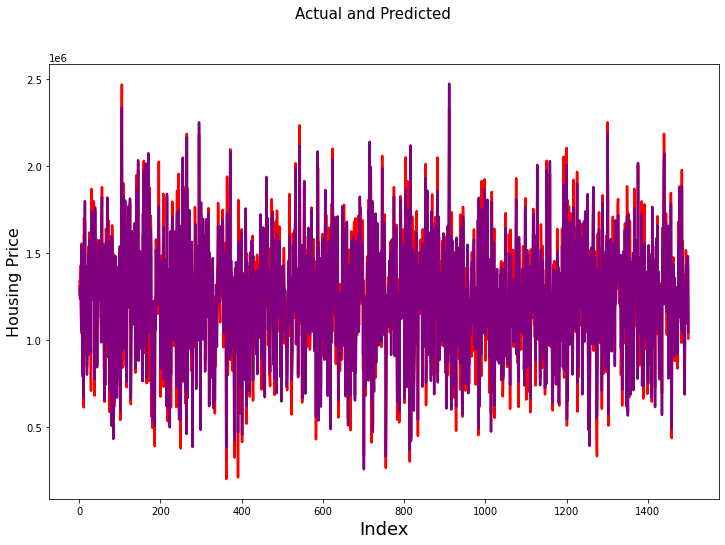

In [32]:
# Actual and Predicted
c = [i for i in range(1,1501,1)] # generating index 
fig = plt.figure(figsize=(12,8))
plt.plot(c,y_test, color="red", linewidth=2.5, linestyle="-") #Plotting Actual
plt.plot(c,pred, color="purple",  linewidth=2.5, linestyle="-") #Plotting predicted
fig.suptitle('Actual and Predicted', fontsize=15)              # Plot heading 
plt.xlabel('Index', fontsize=18)                               # X-label
plt.ylabel('Housing Price', fontsize=16)                       # Y-label